In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# create charts folder if it doesn't exist
os.makedirs("charts", exist_ok=True)

print("Libraries loaded!")

Libraries loaded!


In [2]:
# load the dataset
df = pd.read_csv("bmw.csv")

# first look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (10781, 9)

First 5 rows:
       model  year  price transmission  mileage fuelType  tax   mpg  \
0   5 Series  2014  11200    Automatic    67068   Diesel  125  57.6   
1   6 Series  2018  27000    Automatic    14827   Petrol  145  42.8   
2   5 Series  2016  16000    Automatic    62794   Diesel  160  51.4   
3   1 Series  2017  12750    Automatic    26676   Diesel  145  72.4   
4   7 Series  2014  14500    Automatic    39554   Diesel  160  50.4   

   engineSize  
0         2.0  
1         2.0  
2         3.0  
3         1.5  
4         3.0  

Missing values:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


In [3]:
# how many unique models are there
print("Unique models:", df["model"].nunique())
print("\nModel counts:")
print(df["model"].value_counts())

print("\nFuel types:")
print(df["fuelType"].value_counts())

print("\nTransmission types:")
print(df["transmission"].value_counts())

print("\nYear range:", df["year"].min(), "to", df["year"].max())# how many unique models are there
print("Unique models:", df["model"].nunique())
print("\nModel counts:")
print(df["model"].value_counts())

print("\nFuel types:")
print(df["fuelType"].value_counts())

print("\nTransmission types:")
print(df["transmission"].value_counts())

print("\nYear range:", df["year"].min(), "to", df["year"].max())

Unique models: 24

Model counts:
model
3 Series    2443
1 Series    1969
2 Series    1229
5 Series    1056
4 Series     995
X1           804
X3           551
X5           468
X2           288
X4           179
M4           125
6 Series     108
Z4           108
7 Series     106
X6           106
X7            55
i3            43
8 Series      39
M5            29
M3            27
M2            21
i8            17
M6             8
Z3             7
Name: count, dtype: int64

Fuel types:
fuelType
Diesel      7027
Petrol      3417
Hybrid       298
Other         36
Electric       3
Name: count, dtype: int64

Transmission types:
transmission
Semi-Auto    4666
Automatic    3588
Manual       2527
Name: count, dtype: int64

Year range: 1996 to 2020
Unique models: 24

Model counts:
model
3 Series    2443
1 Series    1969
2 Series    1229
5 Series    1056
4 Series     995
X1           804
X3           551
X5           468
X2           288
X4           179
M4           125
6 Series     108
Z4         

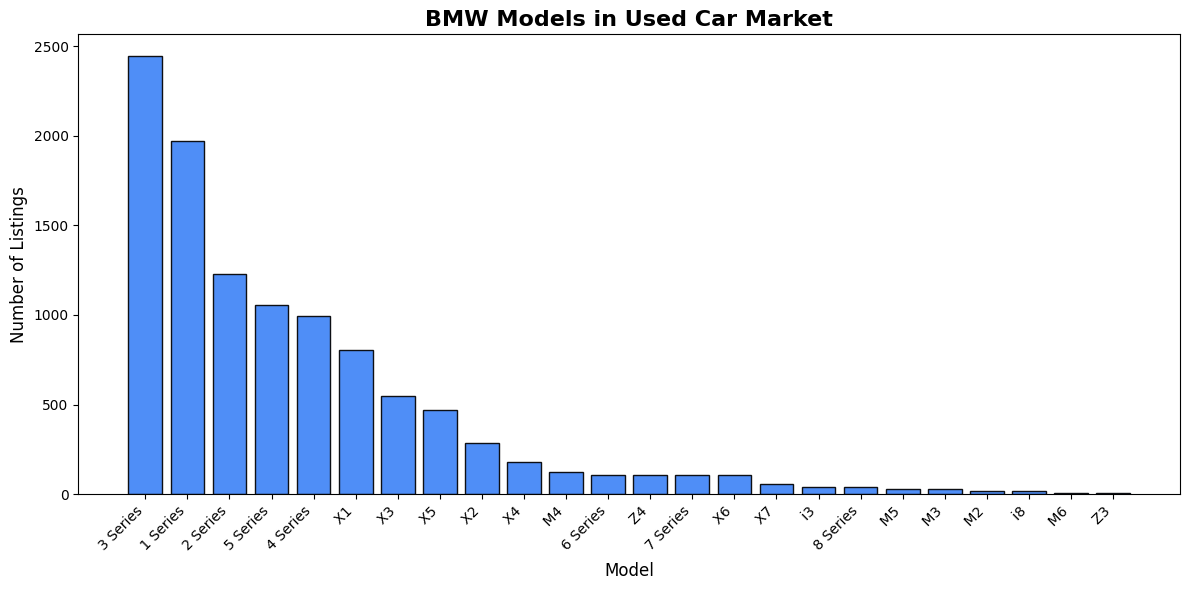

Most listed model:  3 Series with 2443 listings


In [4]:
# question 1: which bmw models appear most in the used market?
model_counts = df["model"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(model_counts.index, model_counts.values, color="#4f8ef7", edgecolor="#0d0f14")

plt.title("BMW Models in Used Car Market", fontsize=16, fontweight="bold")
plt.xlabel("Model", fontsize=12)
plt.ylabel("Number of Listings", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("charts/01_model_counts.png", dpi=150)
plt.show()

print("Most listed model:", model_counts.index[0], "with", model_counts.iloc[0], "listings")

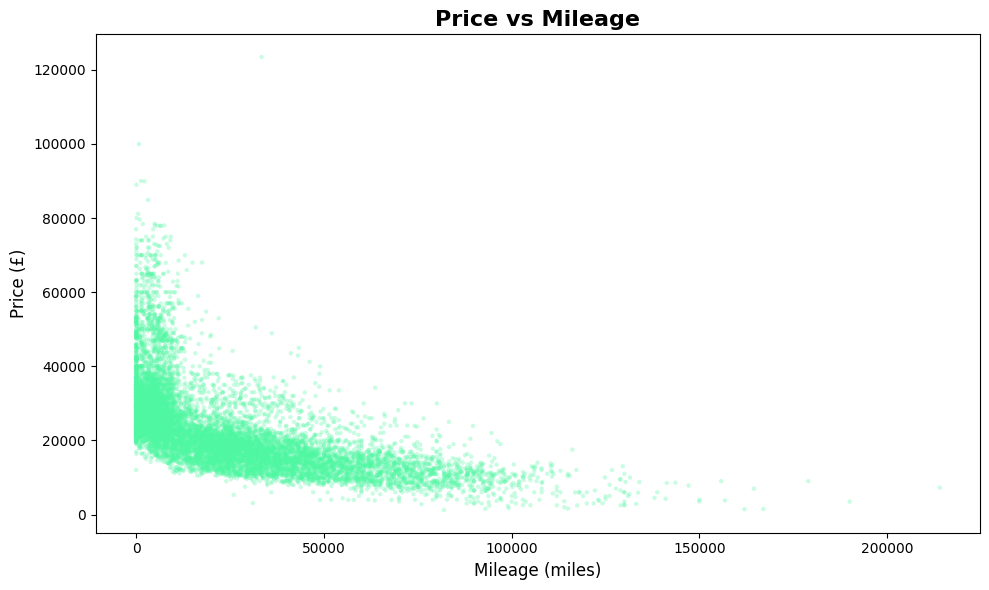

Correlation between mileage and price: -0.61


In [5]:
# question 2: how does price drop as mileage increases?
plt.figure(figsize=(10, 6))
plt.scatter(df["mileage"], df["price"], alpha=0.3, color="#4ff7a2", edgecolor="none", s=10)

plt.title("Price vs Mileage", fontsize=16, fontweight="bold")
plt.xlabel("Mileage (miles)", fontsize=12)
plt.ylabel("Price (£)", fontsize=12)
plt.tight_layout()

plt.savefig("charts/02_price_vs_mileage.png", dpi=150)
plt.show()

# correlation between mileage and price
corr = df["mileage"].corr(df["price"])
print(f"Correlation between mileage and price: {corr:.2f}")

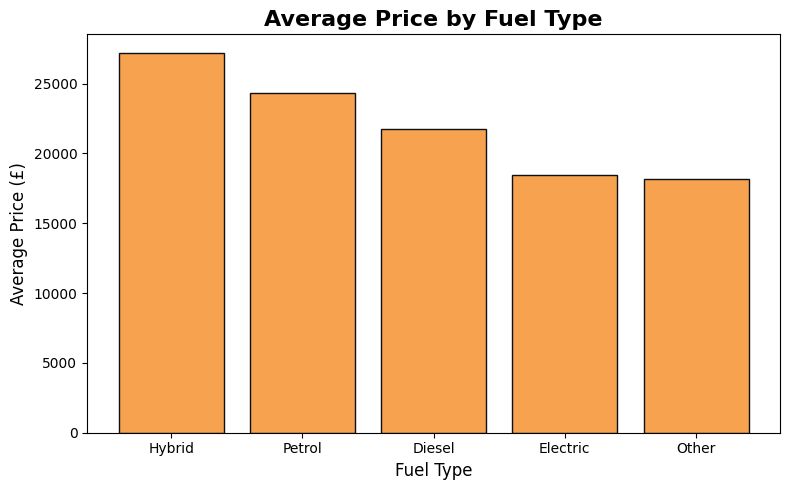

Average price by fuel type:
fuelType
Hybrid      27169.71
Petrol      24360.27
Diesel      21779.26
Electric    18466.00
Other       18193.86
Name: price, dtype: float64


In [6]:
# question 3: which fuel type holds the best resale value?
fuel_avg_price = df.groupby("fuelType")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(fuel_avg_price.index, fuel_avg_price.values, color="#f7a24f", edgecolor="#0d0f14")

plt.title("Average Price by Fuel Type", fontsize=16, fontweight="bold")
plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("Average Price (£)", fontsize=12)
plt.tight_layout()

plt.savefig("charts/03_price_by_fuel.png", dpi=150)
plt.show()

print("Average price by fuel type:")
print(fuel_avg_price.round(2))

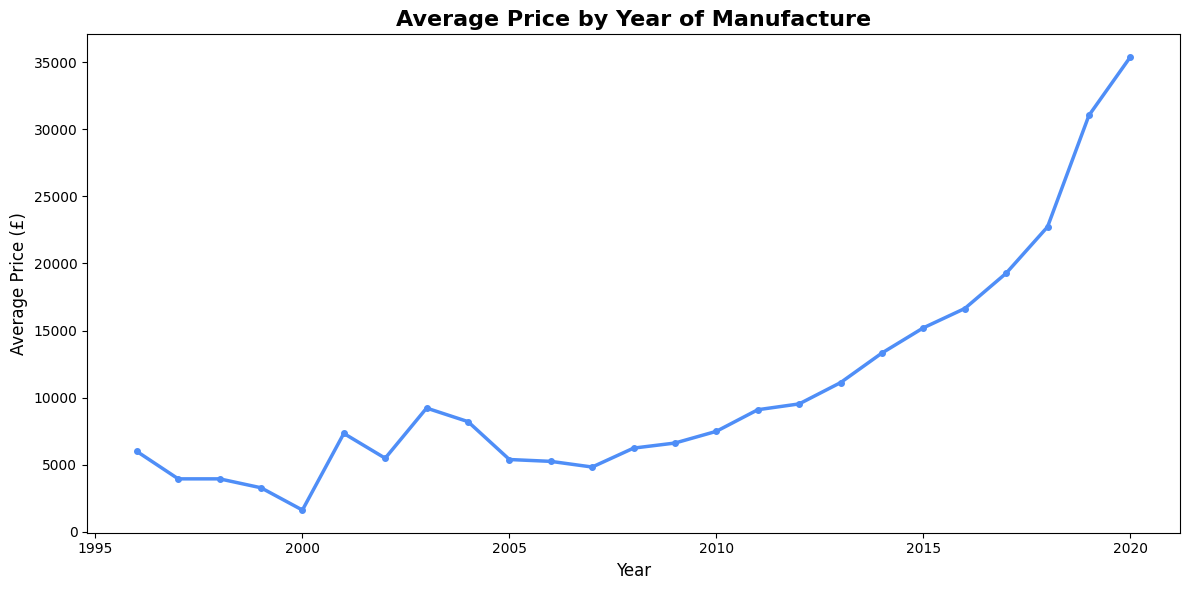

Newest year avg price:  £ 35377.68
Oldest year avg price:  £ 5995.0


In [7]:
# question 4: how does year of manufacture affect price?
year_avg_price = df.groupby("year")["price"].mean()

plt.figure(figsize=(12, 6))
plt.plot(year_avg_price.index, year_avg_price.values, 
         color="#4f8ef7", linewidth=2.5, marker="o", markersize=4)

plt.title("Average Price by Year of Manufacture", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Price (£)", fontsize=12)
plt.tight_layout()

plt.savefig("charts/04_price_by_year.png", dpi=150)
plt.show()

print("Newest year avg price:  £", round(year_avg_price[2020], 2))
print("Oldest year avg price:  £", round(year_avg_price[1996], 2))

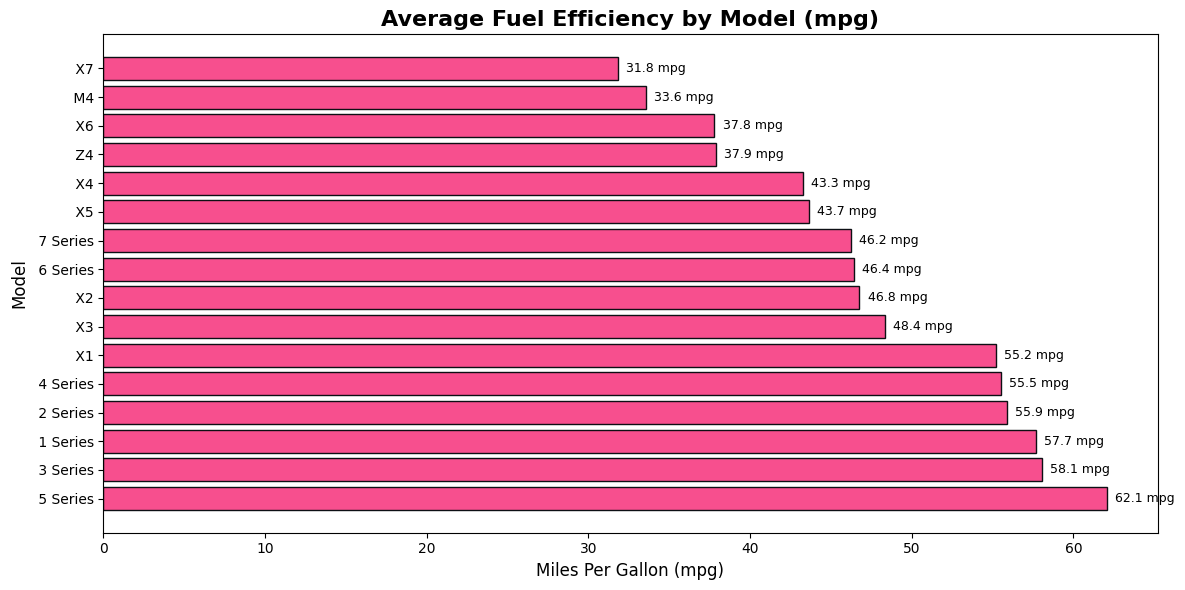

Most fuel efficient model:  5 Series (62.1 mpg)
Least fuel efficient model:  X7 (31.8 mpg)


In [8]:
# question 6: which bmw model has the best fuel efficiency?
# only using models with enough listings to be meaningful
popular_models = df["model"].value_counts()[df["model"].value_counts() > 50].index
df_popular = df[df["model"].isin(popular_models)]

model_mpg = df_popular.groupby("model")["mpg"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.barh(model_mpg.index, model_mpg.values, color="#f74f8e", edgecolor="#0d0f14")

plt.title("Average Fuel Efficiency by Model (mpg)", fontsize=16, fontweight="bold")
plt.xlabel("Miles Per Gallon (mpg)", fontsize=12)
plt.ylabel("Model", fontsize=12)

# add value labels
for bar, val in zip(bars, model_mpg.values):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val:.1f} mpg", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("charts/06_mpg_by_model.png", dpi=150)
plt.show()

print("Most fuel efficient model:", model_mpg.index[0], f"({model_mpg.iloc[0]:.1f} mpg)")
print("Least fuel efficient model:", model_mpg.index[-1], f"({model_mpg.iloc[-1]:.1f} mpg)")